Neo Hooke modell, kompresszibilis eset - Paraméterillesztés mérési adatsorra

In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.optimize import least_squares


lam1, lam2, lam3 = sp.symbols('lam1 lam2 lam3', positive=True)
lam1v, lam2v, lam3v = sp.symbols('lam1v lam2v lam3v')
C10, D1 = sp.symbols(
    'C10 D1',
    positive=True
)
lamT = sp.symbols('lamT', positive=True)

# Initial parameter values (used only for evaluation)
D1_val = 1.33e-9
C10_val = 200000

J = lam1 * lam2 * lam3

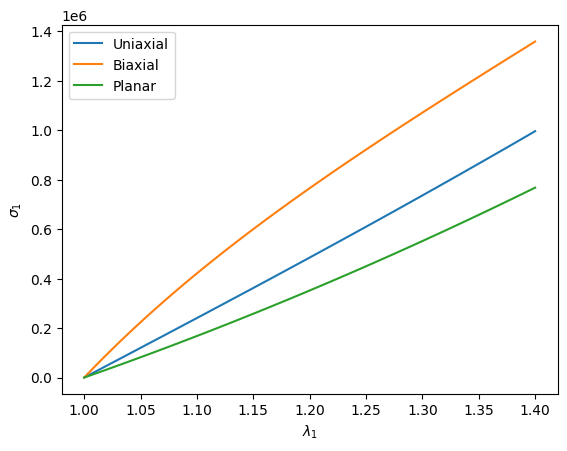

In [6]:
# ---------------------------------------------------------------------
# Symbolic expressions
# ---------------------------------------------------------------------

WD = 2 * C10 * (lam1v**2 + lam2v**2 + lam3v**2 - 3)

WV = (J - 1)**2 / D1

W = (WD + WV).subs({
    lam1v: lam1 * J**(-sp.Rational(1, 3)),
    lam2v: lam2 * J**(-sp.Rational(1, 3)),
    lam3v: lam3 * J**(-sp.Rational(1, 3))
})

W = sp.simplify(W)

P1 = sp.simplify(sp.diff(W, lam1))
P2 = sp.simplify(sp.diff(W, lam2))

# ---------------------------------------------------------------------
# Boundary conditions
# ---------------------------------------------------------------------

BC = {
    "uniax": {
        lam2: lamT,
        lam3: lamT,
    },

    # Loading in directions 1 and 3, free transverse direction = 2
    "biax": {
        lam2: lamT,
        lam3: lam1,
    },

    "planar": {
        lam2: 1,
        lam3: lamT,
    }
}

# ---------------------------------------------------------------------
# Symbolic expressions for each loading case
# ---------------------------------------------------------------------

P1_case = {
    name: sp.simplify(P1.subs(subs))
    for name, subs in BC.items()
}

P2_case = {
    name: sp.simplify(P2.subs(subs))
    for name, subs in BC.items()
}

# ---------------------------------------------------------------------
# Lambdified functions
# ---------------------------------------------------------------------

P1_fun = {
    name: sp.lambdify(
        (
            lam1,
            lamT,
            C10,
            D1
        ),
        expr,
        modules="numpy"
    )
    for name, expr in P1_case.items()
}

P2_fun = {
    name: sp.lambdify(
        (
            lam1,
            lamT,
            C10,
            D1
        ),
        expr,
        modules="numpy"
    )
    for name, expr in P2_case.items()
}

# ---------------------------------------------------------------------
# Solve traction-free transverse direction (P22 = 0)
# ---------------------------------------------------------------------

def solve_transverse(
    case,
    lamT_init,
    lam1val,
    C10v,
    D1v
):

    f = lambda lt: P2_fun[case](
        lam1val,
        lt,
        C10v,
        D1v
    )

    sol = root_scalar(
        f,
        x0=lamT_init,
        x1=lamT_init + 1e-4,
        method="secant"
    )

    return sol.root

# ---------------------------------------------------------------------
# Compute stress-stretch curve
# ---------------------------------------------------------------------

def compute_NH_curve(
    case,
    lam1vals,
    C10v,
    D1v
):

    n = len(lam1vals)

    lamT_vals = np.ones(n)
    P1_vals = np.zeros(n)
    Sigma1_vals = np.zeros(n)

    for i in range(n):

        if i == 0:
            guess = 1.0
        else:
            guess = lamT_vals[i - 1]

        lamT_vals[i] = solve_transverse(
            case,
            guess,
            lam1vals[i],
            C10v,
            D1v
        )

        P1_vals[i] = P1_fun[case](
            lam1vals[i],
            lamT_vals[i],
            C10v,
            D1v
        )

        Sigma1_vals[i] = lam1vals[i] * P1_vals[i]

    return lamT_vals, P1_vals, Sigma1_vals

# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

params = (
    C10_val,
    D1_val
)

# ---------------------------------------------------------------------
# Compute curves
# ---------------------------------------------------------------------

n = 100
lam1vals = np.linspace(1.0, 1.4, n)

lamT_uniax, P1_uniax_vals, Sigma1_uniax_vals = compute_NH_curve(
    "uniax",
    lam1vals,
    *params
)

lamT_biax, P1_biax_vals, Sigma1_biax_vals = compute_NH_curve(
    "biax",
    lam1vals,
    *params
)

lamT_planar, P1_planar_vals, Sigma1_planar_vals = compute_NH_curve(
    "planar",
    lam1vals,
    *params
)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots()

ax.plot(lam1vals, Sigma1_uniax_vals, label="Uniaxial")
ax.plot(lam1vals, Sigma1_biax_vals, label="Biaxial")
ax.plot(lam1vals, Sigma1_planar_vals, label="Planar")

ax.set_xlabel(r"$\lambda_1$")
ax.set_ylabel(r"$\sigma_1$")
ax.legend()

plt.show()

C10 = 201332
D1  = 1.00002e-12


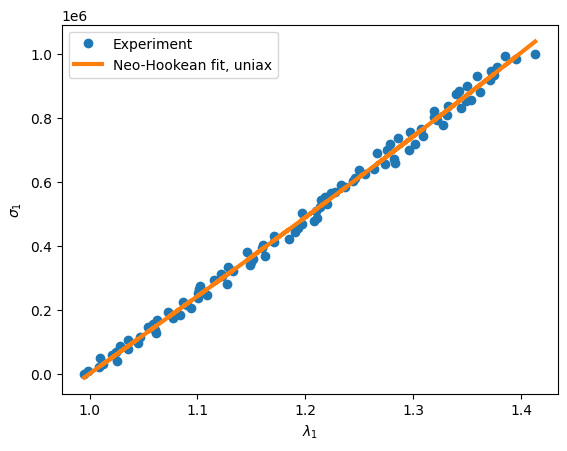

In [7]:
# ---------------------------------------------------------------------
# Synthetic experimental data
# ---------------------------------------------------------------------

lam1_data = lam1vals * np.random.uniform(0.99, 1.01, len(lam1vals))
sigma1_data = Sigma1_uniax_vals * np.random.uniform(0.99, 1.01, len(lam1vals))

# ---------------------------------------------------------------------
# Forward model
# ---------------------------------------------------------------------

def predict_sigma1(case, lam1vals, C10, D1):

    _, _, sigma1 = compute_NH_curve(
        case,
        lam1vals,
        C10,
        D1
    )

    return sigma1

# ---------------------------------------------------------------------
# Residuals
# ---------------------------------------------------------------------

def residuals(params, case, lam1_exp, sigma_exp):

    C10, D1 = params

    sigma_pred = predict_sigma1(
        case,
        lam1_exp,
        C10,
        D1
    )

    return sigma_pred - sigma_exp

# ---------------------------------------------------------------------
# Initial guess
# ---------------------------------------------------------------------

p0 = np.array([
    2e5,      # C10
    1e-9      # D1
])

# ---------------------------------------------------------------------
# Bounds
# ---------------------------------------------------------------------

bound_lower = [1e3, 1e-12]
bound_upper = [1e7, 1e-6]

# ---------------------------------------------------------------------
# Fit
# ---------------------------------------------------------------------

result = least_squares(
    residuals,
    p0,
    bounds=(bound_lower, bound_upper),
    args=("uniax", lam1_data, sigma1_data)
)

C10_fit, D1_fit = result.x

print(f"C10 = {C10_fit:.6g}")
print(f"D1  = {D1_fit:.6g}")

# ---------------------------------------------------------------------
# Fitted curve
# ---------------------------------------------------------------------

sigma1_fit = predict_sigma1(
    "uniax",
    lam1_data,
    C10_fit,
    D1_fit
)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

plt.figure()

plt.plot(lam1_data, sigma1_data, 'o', label='Experiment')
plt.plot(lam1_data, sigma1_fit, '-', linewidth=3, label='Neo-Hookean fit, uniax')

plt.xlabel(r'$\lambda_1$')
plt.ylabel(r'$\sigma_1$')
plt.legend()

plt.show()